<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/Montecarlo1_Log%C3%ADstica%20Integral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RESUMEN DE LA SIMULACIÓN MONTE CARLO
-----------------------------------
Utilidad promedio: 6019.88 USD
Utilidad mínima: -5353.87 USD
Utilidad máxima: 20780.93 USD
Probabilidad de pérdida: 3.52 %
Probabilidad de margen mayor al 15%: 53.82 %


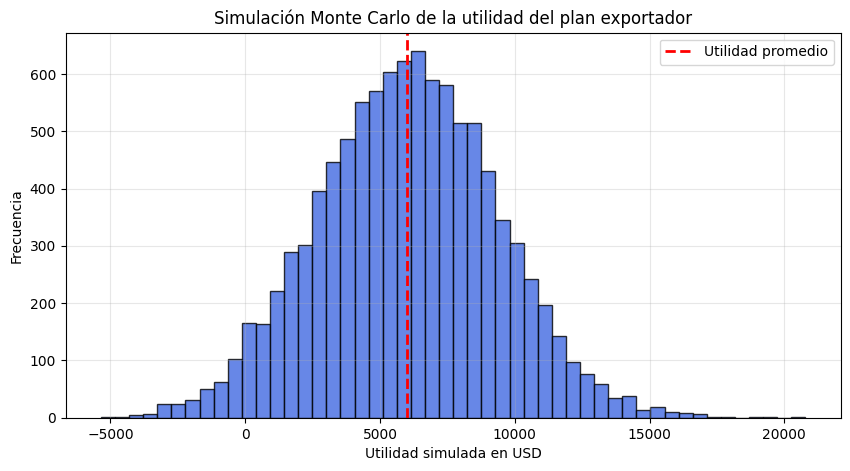


INTERPRETACIÓN DE LA GRÁFICA DE UTILIDAD
La gráfica muestra los posibles resultados de utilidad del proyecto exportador.
Si la mayoría de barras están a la derecha de cero, el proyecto tiende a ser rentable.
La línea roja representa la utilidad promedio esperada.
Los valores negativos representan escenarios de pérdida que deben gestionarse.


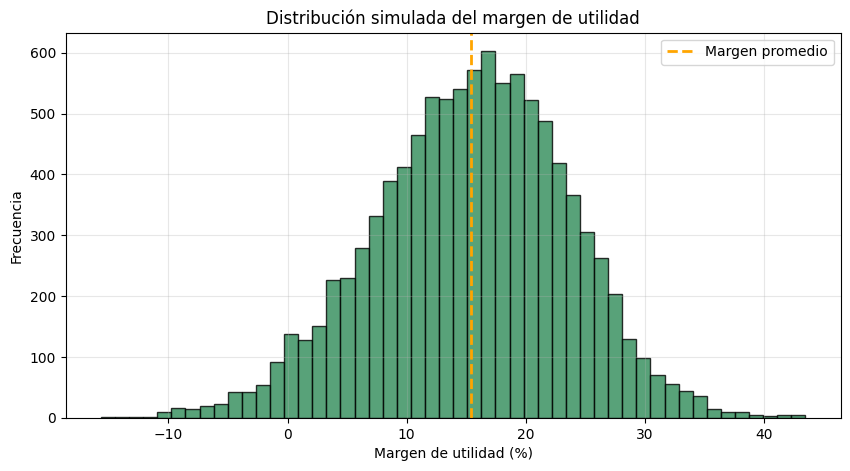


INTERPRETACIÓN DE LA GRÁFICA DE MARGEN
Esta gráfica muestra cómo puede variar el margen de utilidad del proyecto.
Los márgenes positivos indican escenarios rentables.
Los márgenes negativos indican escenarios de pérdida.
Un margen superior al 15% puede considerarse atractivo, dependiendo del sector.

CLASIFICACIÓN DE ESCENARIOS
Escenario
Rentabilidad alta     6213
Rentabilidad media    2616
Rentabilidad baja      819
Pérdida                352
Name: count, dtype: int64


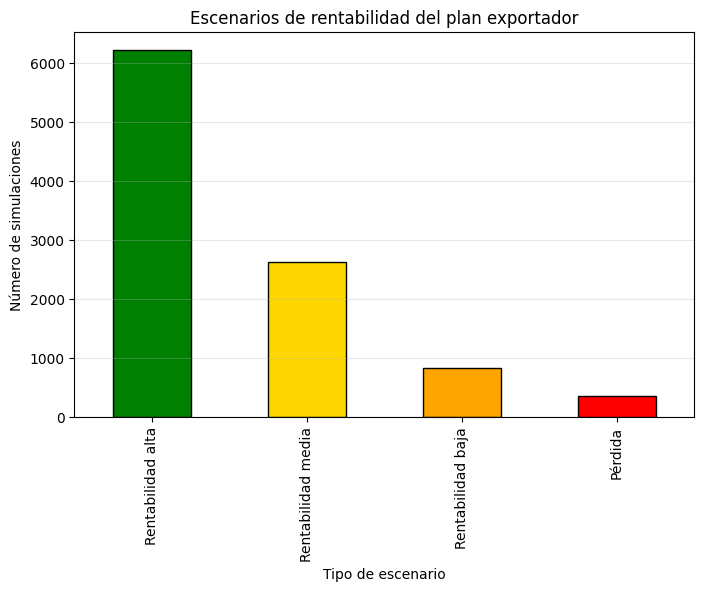


INTERPRETACIÓN DE LA GRÁFICA DE ESCENARIOS
Esta gráfica clasifica los resultados en niveles de rentabilidad.
Si predominan los escenarios de rentabilidad alta o media, el proyecto es viable.
Si aparecen muchos escenarios de pérdida, se deben revisar precio, costos, DFI o volumen.
Esta clasificación ayuda a tomar decisiones antes de ejecutar la exportación.


In [1]:
# ============================================================
# SIMULACIÓN MONTE CARLO PARA UN PLAN LOGÍSTICO EXPORTADOR
# ============================================================
# Objetivo:
# Simular diferentes escenarios posibles de rentabilidad
# considerando que en una exportación los costos, precios,
# cantidades y gastos logísticos pueden cambiar.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ZONA 1: CONFIGURACIÓN GENERAL
# ============================================================
# No es necesario cambiar este dato.
# 10.000 simulaciones permiten analizar muchos escenarios posibles.

simulaciones = 10000


# ============================================================
# ZONA 2: DATOS BASE DEL PROYECTO
# ============================================================
# AQUÍ SÍ DEBEN CAMBIAR LOS DATOS SEGÚN SU PLAN EXPORTADOR.
#
# Ejemplos:
# Si exportan café: cantidad puede ser sacos.
# Si exportan flores: cantidad puede ser ramos o cajas.
# Si exportan frutas: cantidad puede ser kg o cajas.
# Si exportan camisetas: cantidad puede ser unidades.
# ============================================================

cantidad_base = 10000              # CAMBIAR: cantidad esperada a exportar
costo_produccion_base = 3.00       # CAMBIAR: costo de producción por unidad en USD
dfi_base = 0.25                    # CAMBIAR: costo DFI por unidad en USD
precio_base = 3.85                 # CAMBIAR: precio de venta internacional por unidad en USD

# Nota:
# DFI significa Distribución Física Internacional.
# Puede incluir:
# transporte internacional,
# seguros,
# aduanas,
# embalaje,
# manipulación,
# documentación,
# almacenamiento,
# inspecciones,
# y otros costos logísticos.


# ============================================================
# ZONA 3: VARIABILIDAD O INCERTIDUMBRE
# ============================================================
# AQUÍ TAMBIÉN PUEDEN AJUSTAR LOS VALORES.
#
# La variabilidad indica cuánto puede cambiar cada variable
# respecto al valor esperado.
#
# Si el mercado es muy incierto: aumenten estos valores.
# Si el mercado es estable: reduzcan estos valores.
# ============================================================

variacion_cantidad = 800              # CAMBIAR: variación posible de la cantidad exportada
variacion_costo_produccion = 0.25     # CAMBIAR: variación posible del costo de producción
variacion_dfi = 0.08                  # CAMBIAR: variación posible de la DFI
variacion_precio_venta = 0.20         # CAMBIAR: variación posible del precio de venta


# ============================================================
# ZONA 4: GENERACIÓN DE ESCENARIOS ALEATORIOS
# ============================================================
# Esta parte crea miles de escenarios posibles.
#
# np.random.normal(valor_promedio, variación, número_simulaciones)
#
# No es necesario modificar esta parte.
# ============================================================

cantidad = np.random.normal(cantidad_base, variacion_cantidad, simulaciones)
costo_produccion = np.random.normal(costo_produccion_base, variacion_costo_produccion, simulaciones)
dfi = np.random.normal(dfi_base, variacion_dfi, simulaciones)
precio_venta = np.random.normal(precio_base, variacion_precio_venta, simulaciones)


# ============================================================
# ZONA 5: EVITAR VALORES NEGATIVOS
# ============================================================
# En la realidad no existen cantidades, precios o costos negativos.
# Por eso se reemplazan valores negativos por cero.
#
# No modificar.
# ============================================================

cantidad = np.maximum(cantidad, 0)
costo_produccion = np.maximum(costo_produccion, 0)
dfi = np.maximum(dfi, 0)
precio_venta = np.maximum(precio_venta, 0)


# ============================================================
# ZONA 6: CÁLCULOS FINANCIEROS
# ============================================================
# Fórmulas:
#
# Costo total unitario = costo de producción + DFI
# Ingresos = precio de venta x cantidad
# Costos totales = costo total unitario x cantidad
# Utilidad = ingresos - costos totales
# Margen de utilidad = utilidad / ingresos
#
# No modificar.
# ============================================================

costo_total_unitario = costo_produccion + dfi
ingresos = precio_venta * cantidad
costos_totales = costo_total_unitario * cantidad
utilidad = ingresos - costos_totales
margen_utilidad = utilidad / ingresos


# ============================================================
# ZONA 7: TABLA DE RESULTADOS
# ============================================================
# Esta tabla guarda todos los escenarios simulados.
# No modificar.
# ============================================================

resultados = pd.DataFrame({
    "Cantidad exportada": cantidad,
    "Costo producción USD/unidad": costo_produccion,
    "DFI USD/unidad": dfi,
    "Precio venta USD/unidad": precio_venta,
    "Costo total USD/unidad": costo_total_unitario,
    "Ingresos USD": ingresos,
    "Costos totales USD": costos_totales,
    "Utilidad USD": utilidad,
    "Margen utilidad": margen_utilidad
})


# ============================================================
# ZONA 8: RESUMEN DE RESULTADOS
# ============================================================
# Esta parte imprime los principales indicadores de análisis.
# ============================================================

print("RESUMEN DE LA SIMULACIÓN MONTE CARLO")
print("-----------------------------------")
print("Utilidad promedio:", round(resultados["Utilidad USD"].mean(), 2), "USD")
print("Utilidad mínima:", round(resultados["Utilidad USD"].min(), 2), "USD")
print("Utilidad máxima:", round(resultados["Utilidad USD"].max(), 2), "USD")
print("Probabilidad de pérdida:", round((resultados["Utilidad USD"] < 0).mean() * 100, 2), "%")
print("Probabilidad de margen mayor al 15%:", round((resultados["Margen utilidad"] > 0.15).mean() * 100, 2), "%")


# ============================================================
# ZONA 9: GRÁFICA DE UTILIDAD
# ============================================================
# Esta gráfica muestra la distribución de utilidades posibles.
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    resultados["Utilidad USD"],
    bins=50,
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    resultados["Utilidad USD"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Utilidad promedio"
)

plt.title("Simulación Monte Carlo de la utilidad del plan exportador")
plt.xlabel("Utilidad simulada en USD")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nINTERPRETACIÓN DE LA GRÁFICA DE UTILIDAD")
print("La gráfica muestra los posibles resultados de utilidad del proyecto exportador.")
print("Si la mayoría de barras están a la derecha de cero, el proyecto tiende a ser rentable.")
print("La línea roja representa la utilidad promedio esperada.")
print("Los valores negativos representan escenarios de pérdida que deben gestionarse.")


# ============================================================
# ZONA 10: GRÁFICA DEL MARGEN DE UTILIDAD
# ============================================================
# Esta gráfica muestra la rentabilidad porcentual del proyecto.
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    resultados["Margen utilidad"] * 100,
    bins=50,
    color="seagreen",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    (resultados["Margen utilidad"] * 100).mean(),
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Margen promedio"
)

plt.title("Distribución simulada del margen de utilidad")
plt.xlabel("Margen de utilidad (%)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nINTERPRETACIÓN DE LA GRÁFICA DE MARGEN")
print("Esta gráfica muestra cómo puede variar el margen de utilidad del proyecto.")
print("Los márgenes positivos indican escenarios rentables.")
print("Los márgenes negativos indican escenarios de pérdida.")
print("Un margen superior al 15% puede considerarse atractivo, dependiendo del sector.")


# ============================================================
# ZONA 11: CLASIFICACIÓN DE ESCENARIOS
# ============================================================
# AQUÍ PUEDEN AJUSTAR LOS RANGOS SI EL PROYECTO ES MÁS PEQUEÑO
# O MÁS GRANDE.
#
# Ejemplo:
# Para un proyecto pequeño, rentabilidad baja puede ser menor a 500 USD.
# Para un proyecto grande, rentabilidad baja puede ser menor a 10.000 USD.
# ============================================================

def clasificar_escenario(utilidad):
    if utilidad < 0:
        return "Pérdida"
    elif utilidad < 2000:
        return "Rentabilidad baja"
    elif utilidad < 5000:
        return "Rentabilidad media"
    else:
        return "Rentabilidad alta"


resultados["Escenario"] = resultados["Utilidad USD"].apply(clasificar_escenario)

conteo_escenarios = resultados["Escenario"].value_counts()

print("\nCLASIFICACIÓN DE ESCENARIOS")
print(conteo_escenarios)


# ============================================================
# ZONA 12: GRÁFICA DE ESCENARIOS
# ============================================================
# Esta gráfica muestra cuántas simulaciones quedaron en:
# pérdida, rentabilidad baja, media o alta.
# ============================================================

colores = {
    "Rentabilidad alta": "green",
    "Rentabilidad media": "gold",
    "Rentabilidad baja": "orange",
    "Pérdida": "red"
}

plt.figure(figsize=(8, 5))

conteo_escenarios.plot(
    kind="bar",
    color=[colores[x] for x in conteo_escenarios.index],
    edgecolor="black"
)

plt.title("Escenarios de rentabilidad del plan exportador")
plt.xlabel("Tipo de escenario")
plt.ylabel("Número de simulaciones")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\nINTERPRETACIÓN DE LA GRÁFICA DE ESCENARIOS")
print("Esta gráfica clasifica los resultados en niveles de rentabilidad.")
print("Si predominan los escenarios de rentabilidad alta o media, el proyecto es viable.")
print("Si aparecen muchos escenarios de pérdida, se deben revisar precio, costos, DFI o volumen.")
print("Esta clasificación ayuda a tomar decisiones antes de ejecutar la exportación.")